In [1]:
print("hi")

hi


#### Agentchat API with Assistant Agent

In [2]:
import os
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")


In [3]:
# Model
model_client=OpenAIChatCompletionClient(model="gpt-4o-mini",api_key=api_key)

In [7]:
my_assistant = AssistantAgent(model_client=model_client, name="Assistant")

In [9]:
result=await my_assistant.run(task="Who are you?")
print(result)

messages=[TextMessage(id='d3e0a067-894b-4e9f-8e14-b268a4f68fd5', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 29, 18, 282711, tzinfo=datetime.timezone.utc), content='Who are you?', type='TextMessage'), TextMessage(id='5e05d380-892a-40d0-85a4-4f48b6da2b65', source='Assistant', models_usage=RequestUsage(prompt_tokens=40, completion_tokens=23), metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 29, 20, 967874, tzinfo=datetime.timezone.utc), content='I am an AI assistant designed to help you with various tasks and provide information. How can I assist you today?', type='TextMessage')] stop_reason=None


[TextMessage(id='d3e0a067-894b-4e9f-8e14-b268a4f68fd5', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 29, 18, 282711, tzinfo=datetime.timezone.utc), content='Who are you?', type='TextMessage'), 

TextMessage(id='5e05d380-892a-40d0-85a4-4f48b6da2b65', source='Assistant', models_usage=RequestUsage(prompt_tokens=40, completion_tokens=23), metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 29, 20, 967874, tzinfo=datetime.timezone.utc), content='I am an AI assistant designed to help you with various tasks and provide information. How can I assist you today?', type='TextMessage')] stop_reason=None

In [ ]:
result=await my_assistant.run(task="What was the last question that I asked?")
print(result)

messages=[TextMessage(id='034baeff-07f3-414c-abf5-6f90635da8dd', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 30, 47, 674324, tzinfo=datetime.timezone.utc), content='What was the same question that I asked?', type='TextMessage'), TextMessage(id='e0d1db9e-a165-4a84-8ddb-45847f91f67d', source='Assistant', models_usage=RequestUsage(prompt_tokens=81, completion_tokens=16), metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 30, 50, 668472, tzinfo=datetime.timezone.utc), content='You asked, "Who are you?" Would you like to ask something else?', type='TextMessage')] stop_reason=None


messages=[TextMessage(id='034baeff-07f3-414c-abf5-6f90635da8dd', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 30, 47, 674324, tzinfo=datetime.timezone.utc), content='What was the same question that I asked?', type='TextMessage'), TextMessage(id='e0d1db9e-a165-4a84-8ddb-45847f91f67d', source='Assistant', models_usage=RequestUsage(prompt_tokens=81, completion_tokens=16), metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 30, 50, 668472, tzinfo=datetime.timezone.utc), content='You asked, "Who are you?" Would you like to ask something else?', type='TextMessage')] stop_reason=None

stateful means -> one that retains memory of previous steps, outcomes, and reasoning across multiple interactions. 

Memory is independent of state. Memory is something that we will set. Eg: Always talk in a polite manner.
What we converse with agent is not memory.

Over time we will be less dependent on state and more on memory.

We can manage the state but not memory, if state becomes too long, model might hallucinate

In [12]:
result=await my_assistant.run(task="What were the last 2 questions that I asked?")
print(result)

messages=[TextMessage(id='48cf778f-169a-42de-bbf0-e65638b59f54', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 44, 17, 825467, tzinfo=datetime.timezone.utc), content='What were the last 2 questions that I asked?', type='TextMessage'), TextMessage(id='7f3b40c9-4876-4f7a-9a24-9e0648b0a266', source='Assistant', models_usage=RequestUsage(prompt_tokens=171, completion_tokens=38), metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 44, 19, 528150, tzinfo=datetime.timezone.utc), content='The last two questions you asked were:\n\n1. "Who are you?"\n2. "What were the last 2 questions that I asked?"\n\nLet me know if you need anything else!', type='TextMessage')] stop_reason=None


messages=[TextMessage(id='48cf778f-169a-42de-bbf0-e65638b59f54', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 44, 17, 825467, tzinfo=datetime.timezone.utc), content='What were the last 2 questions that I asked?', type='TextMessage'), 

TextMessage(id='7f3b40c9-4876-4f7a-9a24-9e0648b0a266', source='Assistant', models_usage=RequestUsage(prompt_tokens=171, completion_tokens=38), metadata={}, created_at=datetime.datetime(2026, 4, 28, 11, 44, 19, 528150, tzinfo=datetime.timezone.utc), content='The last two questions you asked were:\n\n1. "Who are you?"\n2. "What were the last 2 questions that I asked?"\n\nLet me know if you need anything else!', type='TextMessage')] stop_reason=None

In [13]:
agent_state=await my_assistant.save_state()
print(agent_state)

{'type': 'AssistantAgentState', 'version': '1.0.0', 'llm_context': {'messages': [{'content': 'Who are you?', 'source': 'user', 'type': 'UserMessage'}, {'content': 'I am an AI assistant designed to help you with various tasks and provide information. How can I assist you today?', 'thought': None, 'source': 'Assistant', 'type': 'AssistantMessage'}, {'content': 'What was the same question that I asked?', 'source': 'user', 'type': 'UserMessage'}, {'content': 'You asked, "Who are you?" Would you like to ask something else?', 'thought': None, 'source': 'Assistant', 'type': 'AssistantMessage'}, {'content': 'What were the last 2 questions that I asked?', 'source': 'user', 'type': 'UserMessage'}, {'content': 'The last two questions you asked were:\n\n1. "Who are you?"\n2. "What was the same question that I asked?"\n\nHow can I assist you further?', 'thought': None, 'source': 'Assistant', 'type': 'AssistantMessage'}, {'content': 'What were the last 2 questions that I asked?', 'source': 'user', '

#### Multi Modal Capabilities 
    - can send other than text as well to the modal

In [15]:
from io import BytesIO
import PIL
import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image


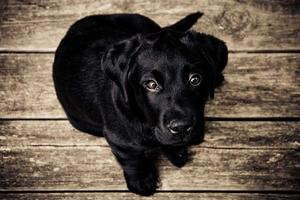

In [16]:
pil_image=PIL.Image.open(BytesIO(requests.get("https://fastly.picsum.photos/id/237/300/200.jpg?hmac=WSdbBEXvCVSqNN1HnCzm7ohp6DhAJfl9t3TcqBNDn_Q").content))
img=Image(pil_image)
multi_modal_message=MultiModalMessage(content=["can you describe the content of this image?", img],source="user")
img

In [17]:
multi_modal_message=MultiModalMessage(content=["What is in the image?", img], source="user")

In [18]:
result=await my_assistant.run(task=multi_modal_message)
print(result)

messages=[MultiModalMessage(id='24e11aa8-3c5e-4870-b73c-0db3933313de', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 38, 6, 506362, tzinfo=datetime.timezone.utc), content=['What is in the image?', <autogen_core._image.Image object at 0x7a0532cfb560>], type='MultiModalMessage'), TextMessage(id='4b41f030-7e80-4d3e-8d58-f34fcf4c3643', source='Assistant', models_usage=RequestUsage(prompt_tokens=8724, completion_tokens=34), metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 38, 38, 290860, tzinfo=datetime.timezone.utc), content='The image appears to be of a black puppy, likely a Labrador, sitting on a wooden surface. If you have any specific questions about it, feel free to ask!', type='TextMessage')] stop_reason=None


messages=[MultiModalMessage(id='24e11aa8-3c5e-4870-b73c-0db3933313de', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 38, 6, 506362, tzinfo=datetime.timezone.utc), content=['What is in the image?', <autogen_core._image.Image object at 0x7a0532cfb560>], type='MultiModalMessage'), 

TextMessage(id='4b41f030-7e80-4d3e-8d58-f34fcf4c3643', source='Assistant', models_usage=RequestUsage(prompt_tokens=8724, completion_tokens=34), metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 38, 38, 290860, tzinfo=datetime.timezone.utc), content='The image appears to be of a black puppy, likely a Labrador, sitting on a wooden surface. If you have any specific questions about it, feel free to ask!', type='TextMessage')] stop_reason=None

Capability to support multi-modal depends on the LLM that we use 

In [19]:
from pydantic import BaseModel

In [20]:
class PlaneInfo(BaseModel):
    name: str
    color: str
    distance:str
    

In [21]:
structure_model_client=OpenAIChatCompletionClient(model="gpt-4o-mini",api_key=api_key, response_format=PlaneInfo)

In [22]:
my_assistant2 = AssistantAgent(model_client=structure_model_client, name="Assistant2")

In [24]:
result=await my_assistant2.run(task="Who are you?")
print(result)

messages=[TextMessage(id='f1c0753d-4749-4e38-8939-f6823c48c8cc', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 53, 45, 649435, tzinfo=datetime.timezone.utc), content='Who are you?', type='TextMessage'), TextMessage(id='73b778b1-0340-4114-b038-6e77dc993d9a', source='Assistant2', models_usage=RequestUsage(prompt_tokens=130, completion_tokens=16), metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 53, 48, 162957, tzinfo=datetime.timezone.utc), content='{"name":"AI Assistant","color":"N/A","distance":"N/A"}', type='TextMessage')] stop_reason=None


messages=[TextMessage(id='f1c0753d-4749-4e38-8939-f6823c48c8cc', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 53, 45, 649435, tzinfo=datetime.timezone.utc), content='Who are you?', type='TextMessage'), TextMessage(id='73b778b1-0340-4114-b038-6e77dc993d9a', source='Assistant2', models_usage=RequestUsage(prompt_tokens=130, completion_tokens=16), metadata={}, created_at=datetime.datetime(2026, 4, 28, 13, 53, 48, 162957, tzinfo=datetime.timezone.utc), 

content='{"name":"AI Assistant","color":"N/A","distance":"N/A"}', type='TextMessage')] stop_reason=None